# Importing Libraries

In [56]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import keras
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings

# Filter warnings


In [57]:
warnings.filterwarnings("ignore")

# Importing Dataset


In [58]:
from pathlib import Path
import os

# Robust dataset path discovery
current_path = Path(os.getcwd())
if (current_path / "ipl.csv").exists():
    data_path = current_path / "ipl.csv"
elif (current_path / "data" / "ipl.csv").exists():
    data_path = current_path / "data" / "ipl.csv"
elif (current_path.parent / "data" / "ipl.csv").exists():
    data_path = current_path.parent / "data" / "ipl.csv"
else:
    raise FileNotFoundError("Could not locate ipl.csv")

ipl = pd.read_csv(data_path)
ipl.head()

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,18-04-2008,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,18-04-2008,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,18-04-2008,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,18-04-2008,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,18-04-2008,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


# Define features (X) and target (y)


In [59]:
ipl.dropna(inplace=True)
df = ipl[['venue', 'bat_team', 'bowl_team', 'wickets', 'overs', 'runs', 'total']]
X = df[['venue', 'bat_team', 'bowl_team', 'wickets', 'overs', 'runs']]
y = df['total']

# Encode categorical features


In [60]:
label_encoders = {}
for feature in ['venue', 'bat_team', 'bowl_team']:
    label_encoders[feature] = preprocessing.LabelEncoder()
    X[feature] = label_encoders[feature].fit_transform(X[feature])

# Split the data into training and testing sets


In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features


In [62]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_test_scaled)

[[0.52941176 0.09090909 0.90909091 0.2        0.06122449 0.00380228]
 [0.26470588 0.18181818 0.09090909 0.3        0.72959184 0.49809886]
 [1.         0.45454545 0.         0.3        0.33673469 0.13688213]
 ...
 [0.20588235 0.63636364 0.36363636 0.         0.07142857 0.05323194]
 [0.35294118 0.90909091 0.         0.3        0.36734694 0.13688213]
 [0.23529412 0.18181818 1.         0.2        0.2244898  0.1026616 ]]


# Build the neural network model


In [63]:
model = keras.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),  # Input layer
    keras.layers.Dense(512, activation='relu'),  # Hidden layer with 512 units and ReLU activation
    keras.layers.Dense(216, activation='relu'),  # Hidden layer with 216 units and ReLU activation
    keras.layers.Dense(1, activation='linear')  # Output layer with linear activation for regression
])

# Define Huber loss function and compile the model


In [64]:
huber_loss = tf.keras.losses.Huber(delta=1.0)
model.compile(optimizer='adam', loss=huber_loss)


# Train the model

In [65]:
model.fit(X_train_scaled, y_train, epochs=50, batch_size=64, validation_data=(X_test_scaled, y_test))

Epoch 1/50
951/951 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 50.3892 - val_loss: 14.6582
Epoch 2/50
951/951 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 15.0707 - val_loss: 14.1942
Epoch 3/50
951/951 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 14.5190 - val_loss: 14.0342
Epoch 4/50
951/951 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 14.5162 - val_loss: 13.8951
Epoch 5/50
951/951 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 14.3342 - val_loss: 13.8587
Epoch 6/50
951/951 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 14.1971 - val_loss: 13.7716
Epoch 7/50
951/951 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 14.2780 - val_loss: 13.7859
Epoch 8/50
951/951 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 14.2552 - val_loss: 13.7869
Epoch 9/50
951/951 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 14.2457 - val_loss: 13.6921
Epoch 10/50
951/951 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 14.1480 - val_loss: 13.7609
Epoch 11/50
951/951 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 14.1446 - val_loss: 13.8091
Epoch 12/50
951/951 ━━━━━━━━━━

# Plot the losses

<Axes: >

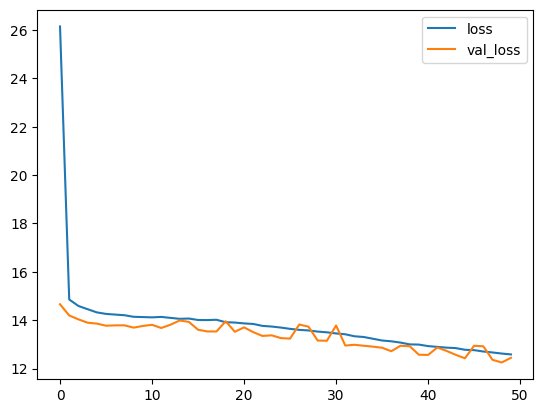

In [66]:
model_losses = pd.DataFrame(model.history.history)
model_losses.plot()

# Model Evaluation

In [67]:
predictions = model.predict(X_test_scaled)

from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test,predictions)


476/476 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


12.932475000135696

# Live Cricket Match Score Prediction Function

In [68]:
def predict_score(venue, batting_team, bowling_team, current_wickets, current_overs, current_runs):
    with output:
        clear_output()

        # Encode categorical features
        venue_encoded = label_encoders['venue'].transform([venue])[0]
        batting_team_encoded = label_encoders['bat_team'].transform([batting_team])[0]
        bowling_team_encoded = label_encoders['bowl_team'].transform([bowling_team])[0]

        # Create input array with encoded categorical features and numerical features
        input_data = np.array([venue_encoded, batting_team_encoded, bowling_team_encoded,
                               current_wickets, current_overs, current_runs]).reshape(1, -1)

        # Scale the input data
        input_scaled = scaler.transform(input_data)

        # Validate inputs
        if current_wickets < 0 or current_wickets > 9:
            print("Please enter a value for wickets between 0 and 9.")
            return
        elif current_overs < 0 or current_overs > 20:
            print("Please enter a value for overs between 0 and 20.")
            return
        elif current_runs < 0 or current_runs > 470:
            print("Please enter valid runs.")
            return

        # Predict the score
        predicted_score = model.predict(input_scaled)

        # Ensure predicted score is not less than current runs
        predicted_score = max(predicted_score, current_runs)

        print("Predicted Score:", int(predicted_score))

# Widgets for user input


In [69]:
venue_widget = widgets.Dropdown(options=ipl['venue'].unique().tolist(), description='Venue:')
batting_team_widget = widgets.Dropdown(options=ipl['bat_team'].unique().tolist(), description='Batting Team:')
bowling_team_widget = widgets.Dropdown(options=ipl['bowl_team'].unique().tolist(), description='Bowling Team:')
wickets_widget = widgets.IntText(value=None, min=0, max=9, description='Current Wickets:')
overs_widget = widgets.FloatText(value=None, min=0.0, max=20.0, description='Current Overs:')
runs_widget = widgets.IntText(value=None, description='Current Runs:')
predict_button = widgets.Button(description="Predict Score", layout=widgets.Layout(width='200px'))

# Set the width of the sidebar headings
side_bar_labels = [venue_widget, batting_team_widget, bowling_team_widget,
                   wickets_widget, overs_widget, runs_widget]
for label in side_bar_labels:
  label.style.description_width = '100px'
# Output widget for displaying prediction
output = widgets.Output()

# Function to handle button click event
def on_predict_button_clicked(b):
    predict_score(venue_widget.value, batting_team_widget.value, bowling_team_widget.value,
                  wickets_widget.value, overs_widget.value, runs_widget.value)

predict_button.on_click(on_predict_button_clicked)

# Display widgets and output


In [70]:
display(venue_widget, batting_team_widget, bowling_team_widget, overs_widget,
        runs_widget, wickets_widget, predict_button, output)

Dropdown(description='Venue:', options=('M Chinnaswamy Stadium', 'Punjab Cricket Association Stadium, Mohali',…

Dropdown(description='Batting Team:', options=('Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasthan Roya…

Dropdown(description='Bowling Team:', options=('Royal Challengers Bangalore', 'Punjab Kings', 'Delhi Capitals'…

FloatText(value=0.0, description='Current Overs:', style=DescriptionStyle(description_width='100px'))

IntText(value=0, description='Current Runs:', style=DescriptionStyle(description_width='100px'))

IntText(value=0, description='Current Wickets:', style=DescriptionStyle(description_width='100px'))

Button(description='Predict Score', layout=Layout(width='200px'), style=ButtonStyle())

Output()